# LightGBM

In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import sys
sys.path.append('..')

from src.lgbm import train
from src.postprocess import snap
from src.metrics import evaluate

from pathlib import Path

import lightgbm as lgb
import mlflow
import pandas as pd

from src.data import load_data, add_features
from src.split import split_breaths, rc_strata
from src.tracking import EXPERIMENT_NAME

## Data


In [10]:
train_raw = load_data('../data/train.csv')
strata = rc_strata(train_raw)
train_df = add_features(train_raw)
train_part, val_part = split_breaths(train_df, strata)
len(train_part), len(val_part)

(4828800, 1207200)

## Training

1. with all rows

In [11]:
model_all, metrics_all = train(train_part, val_part, run_name='lgbm_all_rows-v3')
metrics_all

2026/10/01 10:31:02 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/10/01 10:31:02 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/10/01 10:31:44 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/zaharguzij/Documents/GitHub/ai301-dl-hw1/.venv/lib/python3.11/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029484 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10751
[LightGBM] [Info] Number of data points in the train set: 4828800, number of used features: 31
[LightGBM] [Info] Start training from score 7.032628
Training until validation scores don't improve for 100 rounds
[250]	train's l1: 0.361332	train's rmse: 0.693414	val's l1: 0.686939	val's rmse: 1.08406
[500]	train's l1: 0.326325	train's rmse: 0.642431	val's l1: 0.657936	val's rmse: 1.04427
[750]	train's l1: 0.30894	train's rmse: 0.619386	val's l1: 0.647777	val's rmse: 1.03095
[1000]	train's l1: 0.296609	train's rmse: 0.602796	val's l1: 0.641341	val's rmse: 1.02179
[1250]	train's l1: 0.288837	train's rmse: 0.592357	val's l1: 0.637481	val's rmse: 1.01631
[1500]	train's l1: 0.281196	train's rmse: 0.581552	val's l1: 0.633621	val's rmse: 1

2026/10/01 10:55:58 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/zaharguzij/Documents/GitHub/ai301-dl-hw1/.venv/lib/python3.11/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/10/01 10:55:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/01 

{'ME': np.float64(0.014717583163556645),
 'MAE': 0.6198801049138533,
 'RMSE': 0.9902681649500696,
 'R2': 0.9884015717371444}

2. only when u_out == 0

In [12]:
model_insp, metrics_insp = train(
    train_part[train_part['u_out'] == 0], val_part, run_name='lgbm_inspiration-v1'
)
metrics_insp

2026/10/01 10:57:33 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/10/01 10:57:33 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/10/01 10:57:50 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/zaharguzij/Documents/GitHub/ai301-dl-hw1/.venv/lib/python3.11/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010832 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10749
[LightGBM] [Info] Number of data points in the train set: 1832954, number of used features: 30
[LightGBM] [Info] Start training from score 15.820396
Training until validation scores don't improve for 100 rounds
[250]	train's l1: 0.523419	train's rmse: 0.914243	val's l1: 0.669966	val's rmse: 1.06757
[500]	train's l1: 0.453223	train's rmse: 0.831976	val's l1: 0.648226	val's rmse: 1.03505
[750]	train's l1: 0.417399	train's rmse: 0.792234	val's l1: 0.639143	val's rmse: 1.02111
[1000]	train's l1: 0.393311	train's rmse: 0.764316	val's l1: 0.633555	val's rmse: 1.01211
[1250]	train's l1: 0.375329	train's rmse: 0.743896	val's l1: 0.630001	val's rmse: 1.00668
[1500]	train's l1: 0.36187	train's rmse: 0.728749	val's l1: 0.627398	val's rmse: 

2026/10/01 11:18:37 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/zaharguzij/Documents/GitHub/ai301-dl-hw1/.venv/lib/python3.11/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/10/01 11:18:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/01 

{'ME': np.float64(0.012343998509342279),
 'MAE': 0.6157171700864756,
 'RMSE': 0.9835794043808179,
 'R2': 0.9885577256125162}

## Results

In [13]:
runs = mlflow.search_runs(
    experiment_names=[EXPERIMENT_NAME], filter_string="tags.mlflow.runName LIKE 'lgbm%'"
)
runs[[
    'tags.mlflow.runName', 'metrics.MAE', 'metrics.RMSE', 'metrics.ME', 'metrics.R2', 'metrics.best_iteration'
]].sort_values('metrics.MAE')

,tags.mlflow.runName,metrics.MAE,metrics.RMSE,metrics.ME,metrics.R2,metrics.best_iteration
0,lgbm_inspiration-v1,0.615717,0.983579,0.012344,0.988558,5000.0
1,lgbm_all_rows-v3,0.619880,0.990268,0.014718,0.988402,4999.0


## Snap to ADC grid

In [14]:
rows = {}
for name, m in {'all_rows': model_all, 'inspiration': model_insp}.items():
    pred = m.predict(val_part[m.feature_name_])
    rows[name] = evaluate(val_part['pressure'], pred, val_part['u_out'])
    rows[f'{name}_snapped'] = evaluate(val_part['pressure'], snap(pred), val_part['u_out'])
pd.DataFrame(rows).T

2026/10/01 11:23:00 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/zaharguzij/Documents/GitHub/ai301-dl-hw1/.venv/lib/python3.11/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/10/01 11:25:25 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/zaharguz

,ME,MAE,RMSE,R2
all_rows,0.014718,0.619880,0.990268,0.988402
all_rows_snapped,0.014575,0.619385,0.990449,0.988397
inspiration,0.012344,0.615717,0.983579,0.988558
inspiration_snapped,0.012307,0.615277,0.983783,0.988553


In [15]:
model = model_all if metrics_all['MAE'] <= metrics_insp['MAE'] else model_insp

## Feature importance


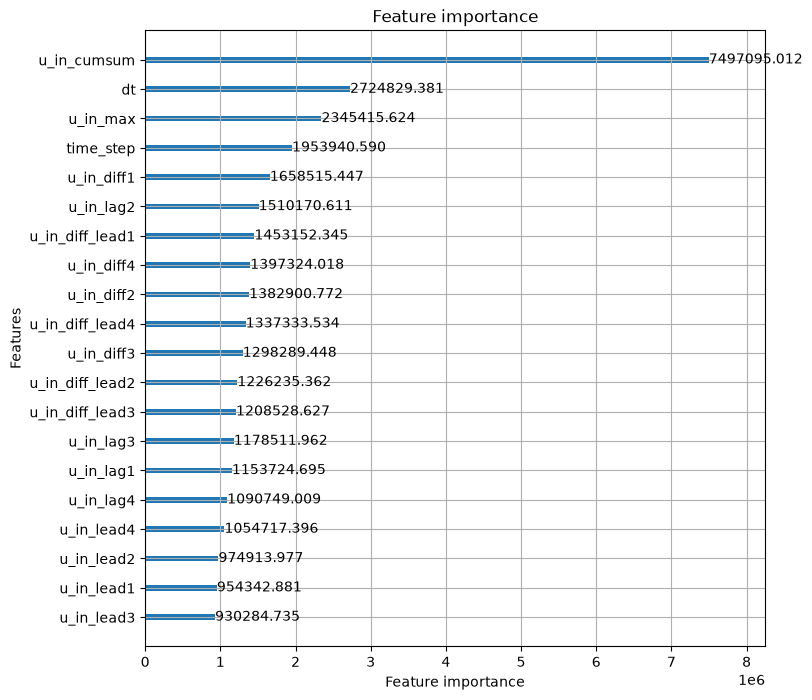

In [16]:
lgb.plot_importance(model, importance_type='gain', max_num_features=20, figsize=(8, 8));

## Kaggle submission


In [17]:
test_df = add_features(load_data('../data/test.csv'))
pred = model.predict(test_df[model.feature_name_])

Path('../submissions').mkdir(exist_ok=True)
for name, p in {'lgbm_raw': pred, 'lgbm_snap': snap(pred)}.items():
    pd.DataFrame({'id': test_df['id'], 'pressure': p}).sort_values('id').to_csv(
        f'../submissions/{name}.csv', index=False
    )

2026/10/01 11:33:04 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/zaharguzij/Documents/GitHub/ai301-dl-hw1/.venv/lib/python3.11/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


In [18]:
!kaggle competitions submit -c ventilator-pressure-prediction -f ../submissions/lgbm_raw.csv -m "lgbm raw"
!kaggle competitions submit -c ventilator-pressure-prediction -f ../submissions/lgbm_snap.csv -m "lgbm + ADC snap"
!kaggle competitions submissions -c ventilator-pressure-prediction | head -5

100%|████████████████████████████████████████| 101M/101M [00:42<00:00, 2.50MB/s]
Successfully submitted to Google Brain - Ventilator Pressure PredictionWarning: Looks like you're using an outdated `kaggle` version (installed: 2.0.0), please consider upgrading to the latest version (2.2.2)
100%|████████████████████████████████████████| 101M/101M [00:42<00:00, 2.50MB/s]
Successfully submitted to Google Brain - Ventilator Pressure PredictionWarning: Looks like you're using an outdated `kaggle` version (installed: 2.0.0), please consider upgrading to the latest version (2.2.2)
fileName               date                        description                                   status                     publicScore  privateScore  
---------------------  --------------------------  --------------------------------------------  -------------------------  -----------  ------------  
lgbm_snap.csv          2026-10-01 08:34:40.730000  lgbm + ADC snap                               SubmissionStatus.PE

- **`lgbm_all_rows-v3`**: trained on all rows (4.83M), with inspiratory and expiratory phases.
- **`lgbm_inspiration-v1`**: trained only on inspiratory rows (`u_out == 0`, 1.83M), the same rows the competition scores.

Validation metrics are computed on `u_out == 0` rows only, by the competition rule:

| Model | Train MAE | Val MAE | Val RMSE | Val ME | Val R² |
|---|---|---|---|---|---|
| all_rows-v3 | 0.244 | 0.6199 | 0.990 | +0.015 | 0.9884 |
| inspiration-v1 | 0.295 | **0.6157** | **0.984** | **+0.012** | **0.9886** |

I submitted the better model, `inspiration-v1`, in two versions: raw predictions, and predictions snapped to the pressure sensor's ADC grid .

| Submission | Val MAE | Kaggle public | Kaggle private |
|---|---|---|---|
| lgbm_raw | 0.6157 | 0.6143 | 0.6164 |
| lgbm_snap | 0.6153 | **0.6138** | **0.6160** |

### Takeaways

- **The validation is reliable.** Val MAE (0.6157) almost matches the Kaggle scores (0.6143 public, 0.6164 private), so the breath-level split reflects the test distribution well.
- **Training on inspiratory rows only is slightly better**, even with 2.6× less data. The expiratory phase adds no useful signal for the scored rows.
- **ADC snapping gives a small but consistent gain** of about 0.0005 MAE, on validation and on both leaderboards.
- **The models capture real pressure dynamics.** Linear regression only reaches MAE 4.97 and R² 0.49.
- **There is noticeable overfitting.** Train MAE is roughly half of validation MAE.
- ME ≈ 0, so there is no systematic bias.